In [1]:
import numpy as np
import fhrr_driver_torch as fd
import torch
from matplotlib import pyplot as plt
import tqdm
import random

In [2]:
space_1 = fd.fhrr_space(10000)
space_2 = fd.fhrr_space(10000)
learned_map = fd.learning_map(space_1, space_2)#, 10, (1000, 1000))
base_1 = space_1.init_random_vec()
base_2 = space_2.init_random_vec()
dims = 2
ssp_1 = [space_1.init_normal_avec() for _ in range(dims)]
ssp_2 = ssp_1

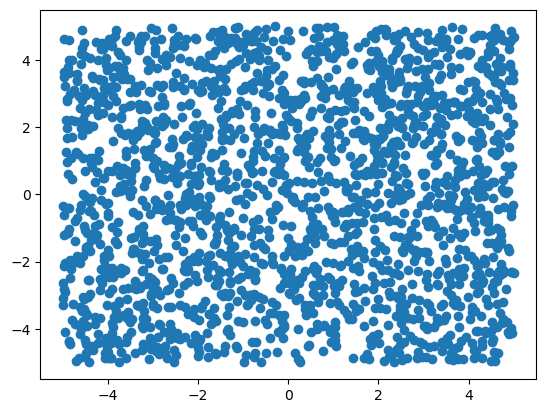

In [8]:
xs = []
ys = []
for _ in range(2000):
    pos = (np.random.rand(dims)-0.5)*10
    xs.append(pos[0])
    ys.append(pos[1])
    vec_1 = space_1.init_ones_vec()*base_1
    vec_2 = space_2.init_ones_vec()*base_2
    for d in range(dims):
        vec_1 *= space_1.ssp_phase(ssp_1[d], pos[d])
        vec_2 *= space_2.ssp_phase(ssp_2[d], pos[d])
    learned_map.learn(vec_1, vec_2)

plt.scatter(xs, ys)

0.16587824078138513


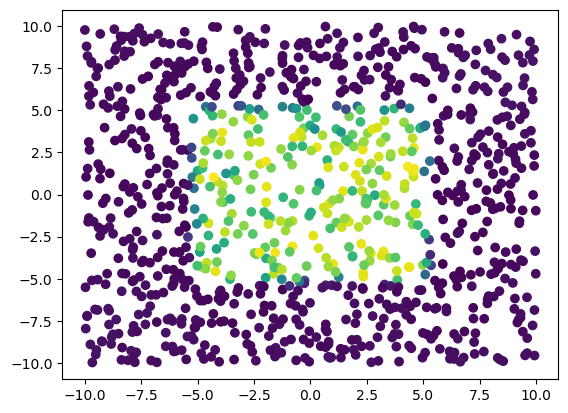

In [9]:
xs = []
ys = []
ss = []
for _ in range(1000):
    pos = (np.random.rand(dims)-0.5)*20
    xs.append(pos[0])
    ys.append(pos[1])
    vec_1 = space_1.init_ones_vec()*base_1
    vec_2 = space_2.init_ones_vec()*base_2
    for d in range(dims):
        vec_1 *= space_1.ssp_phase(ssp_1[d], pos[d])
        vec_2 *= space_2.ssp_phase(ssp_2[d], pos[d])
    p_vec_2 = learned_map.forwards(vec_1)
    ss.append(space_2.similarity_R(vec_2, p_vec_2)[0,0])
plt.scatter(xs, ys, c=ss)
print(np.median(ss))